# COGS 108 - EDA Checkpoint

# Names

- Hamzah Mansuri
- Lukas Fullner
- Jiahao Han
- Daniel Lee
- Jason Trinh

# Research Question

Does the prestige of institutions in a U.S. state--measured as the mean U.S. News & World Report national ranking of its non-graduate colleges--predict lower acceptance rates in that state (total acceptances ÷ total applicants)? 

For example, if State 1's colleges average around the top 10 U.S. news rank (mean = 9), will its acceptance rate be overall lower compared to another state whose colleges average around the top 50 (mean = 37)?

## Background and Prior Work


The college admissions landscape in the United States is shaped by a complex interplay of institutional reputation, geographic location, and applicant behavior. Among the various factors influencing student decisions, the presence of prestigious universities within a state can have far-reaching implications not only for applicants but also for neighboring institutions. While elite colleges attract a high volume of applications due to their academic reputation and resources, their low acceptance rates often lead students to consider alternative schools within the same state. This dynamic raises an important question: Does the presence of a prestigious college in a state affect the acceptance rates of other colleges within that state?

Additionally, it is a common perception after graduating high school students should attend college to improve their future careers. As more students apply to college over time, it consequentially leads to increased competition. Bound et al. (2009) found the percentage of institution applications increased over time (aside from private institutions), however the counterfactual college acceptance rate—a model-based estimate using the 1972 class as a baseline— decreased over time.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) In the counterfactual data, California and the Northeast region had the highest simulated declines in acceptance rates. While over time competition increased nationally, it is unclear whether every state experienced the same severity. For instance, could the acceptance rate of a state stay high because of students enrolling into a "safety" school in proximity of a top-10 university?

The influx of applications has intensified competition at top-tier universities, making admissions more challenging for prospective students. The Axios articled titled "Acceptance rates drop at Virginia's top public universities" highlights the trend in Virginia that most prestgious public institutions are experiencing declining acceptance rates due to a surge in applications.<a name1 = "cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) Although many public four-year universities were affected, many were also able to keep their acceptance rates of 80% and above for in-state students, indicating that many universities remain accessible despite the competitive uprising. This article also touches on outside factors that can influence admissions such as Supreme Court decisions which impact enrollment patterns at these institutions. Given this, while the prestige of certain Virginia colleges can correlate to lower acceptance rates, it does not fully translate to a universally more competitive admission status across the entire state. 

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Bound, J., Hershbein, B., & Long, B. T. (2009). Playing the Admissions Game: Student Reactions to Increasing College Competition. <i>The journal of economic perspectives : a journal of the American Economic Association, 23</i>(4), 119–146. https://doi.org/10.1257/jep.23.4.119

2. <a name1="cite_note-2"></a>[^](#cite_ref-2) Peifer, K. (2024, September 2). Acceptance rates drop at Virginia’s top public universities. https://www.axios.com/local/richmond/2024/09/05/virginias-universities-acceptance-rates-college 

# Hypothesis


We hypothesize that U.S. states with a higher concentration of prestigious universities will have, on average, lower college acceptance rates compared to states with fewer or less prestigous institutions. Prestige will be operationalized using national college rankings and statistics (e.g. US News & IPEDS), and acceptance rate will be measured by the percentage of applicants admitted to four-year institutions in each state. We predict there to be a strong correlation between the number of high-ranking instituions in a state and the average acceptance rate across that state's institutions. 

# Data
The ideal dataset of this question would contain information regarding: Name of the college/university, State the college is located in, total number of applicants to that college, number of accepted applicants, and number of applicants that actually accepted/enrolled. It would ideally contain several thousand observations, possibly tens of thousands separated by academic school year.
Another dataset to keep in mind would be the rankings of colleges as they often change year by year.
Many colleges self-report this information as part of a way to advertise that they are very accepting, or challenging, or a desirable place to be at so we could utilize these self-reported statistics, or a dataset that has already aggregated these stats.
The data should be stored by academic year, then by state as we want to analyze the effect that top colleges have on the acceptance rates across all colleges in that state.

## Data overview

- Dataset #1
  - Dataset Name: Admission considerations, applications, admissions, enrollees and test scores, fall 2023	
  - Link to the dataset: https://nces.ed.gov/ipeds/datacenter/DataFiles.aspx?year=2023&surveyNumber=12&sid=a5bc3f4c-7039-49d4-9bcd-c6fa32f6d1cb&rtid=7
  - File Path to Data: Group059_SP25/Data/Data_5-6-2025.csv
  - Number of observations: 5995
  - Number of variables: 25

- Dataset #2
  - Dataset Name: US News National University Rankings (Top 150) Through 2025
  - Link to the dataset: https://andyreiter.com/datasets/
  - File Path to Data: Group059_SP25/Data/College_Ranking_Data.csv
  - Number of observations: 189
  - Number of variables: 42

**Dataset #1: Admission considerations, applications, admissions, enrollees and test scores, fall 2023**

This dataset is from the Integrated Postsecondaray Education Data System (IPEDS), consisting of info from 2023 related to admission for first-time students looking for a degree. Unlike the first dataset, there are less variables, however it also includes variables the first dataset did not have such as the amount of applicants for each institution. As such, the main variables we will use are `APPLCN` (applicant total), `ADMSSN` (admission total), and `UNITID` (institution ID). Like the previous dataset, as we only need these variables, we need to drop the other columns. This dataset does not have the location or name of institution, so the `UNITID` will allow us  to combine and connect the datasets, as each institution has the same ID. We will use the variables in this data set, such as college rankings for 2023, to help our research by analyzing how the ranking in each state differs and how the avaerage rankings of the state correlate to the overall admission status. We will use this state data to create a geospatial graph that will show us the average university rankings by state. 

**Dataset #2: US News National University Rankings (Top 150) Through 2025**

This dataset is from Andrew G. Reiter, who with the help of Yan Zhang, compiled the top 150 national rankings of the institutions from U.S. News & World Report (going from 1984 to 2025). The main variables we will use are `State` (state postcode), `University Name` (name of institution), `IPEDS` (institution ID), and `2023` (the year 2023, because the other datasets are also from 2023). Like the other two datasets we need to drop the unused columns, which is every other year aside from 2023 for this specific dataset. While this dataset has info that could be combined with the other datasets, such as institution ID, the variable name is incorrect so we would have to rename it to match. The same can be said for the state postcode and institution name, where it would need to be renamed to combine with the first dataset. In this data set, we will use the variables state, number of students admitted, number of students enrolled, and number of students applying. These will be used to create bar plots that will show us the correlation between admission status vs enrollment status as well as those numbers by state. 

## Dataset #1 (College Ranking)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.pyplot import figure

In [2]:
#This is data source 2, where all university rankings are kept
#Import the ranking data file into RankingRaw
url = "Data/College_Ranking_Data_V2.csv"  
RankingRaw = pd.read_csv(url)

# Selecting the Univerity Name, State, IPEDS and year 2023 columns from the RankingRaw
RankingFiltered = RankingRaw[['University Name', 'State', 'IPEDS', '2023']]

# Renaming the columns so keep it concise
RankingFiltered = RankingFiltered.rename(columns={
    'University Name': 'University',
    'State': 'State',
    'IPEDS': 'IPEDS',
    '2023': 'Rank'
})

#Cleaning up data
# Dropping rows with missing values
RankingFiltered = RankingFiltered.dropna().reset_index(drop=True)


## This String conversion is likely redundant but doing it in case

# Converting the State column to string
RankingFiltered['State'] = RankingFiltered['State'].astype(str)
# Converting the University column to string
RankingFiltered['University'] = RankingFiltered['University'].astype(str)


## Converting the Rank, and IPEDS column to Ints

# Converting the Rank column to numeric
RankingFiltered['Rank'] = pd.to_numeric(RankingFiltered['Rank'], errors='coerce')
# Converting the IPEDS column to numeric
RankingFiltered['IPEDS'] = pd.to_numeric(RankingFiltered['IPEDS'], errors='coerce')
# Converting the Rank column to int
RankingFiltered['Rank'] = RankingFiltered['Rank'].astype(int)
# Converting the IPEDS column to int
RankingFiltered['IPEDS'] = RankingFiltered['IPEDS'].astype(int)

# After cleaned up all the data, store all data into RankingCleaned
# Now we ready to use RankingCleaned
RankingCleaned = RankingFiltered

# Now print your DataFrame (Commented out, but you can uncomment it to see the output)
print(RankingCleaned)
# Checking the data types of the columns
print(RankingCleaned.dtypes)

                             University State   IPEDS  Rank
0                   American University    DC  131159    72
1        Arizona State University-Tempe    AZ  104151   121
2                     Auburn University    AL  100858    97
3                     Baylor University    TX  223232    77
4                 Binghamton University    NY  196079    83
..                                  ...   ...     ...   ...
146              Wake Forest University    NC  199847    29
147  Washington University in St. Louis    MO  179867    15
148     Worcester Polytechnic Institute    MA  168421    67
149                     Yale University    CT  130794     3
150                  Yeshiva University    NY  197708    67

[151 rows x 4 columns]
University    object
State         object
IPEDS          int64
Rank           int64
dtype: object


## Dataset #2 (2023 Admission Stats)

In [3]:
#This is data source 1, where all university admission, application, enrollment rate are kept
#Import the ranking data file admission
url = "Data/Data_5-6-2025.csv"
admission = pd.read_csv(url)

# Keep only the first column which is univeristy name and total application column, total admission column, total enrollment column, IPEDS for each univeristy
admission = admission.iloc[:, [0, 1, 2, 11, 12]] 

# Rename those columns to make data readable
admission.columns = ['IPEDS','University', 'Application', 'Admitted', 'Enrolled']

#Convert application, admitted, enrolled data to numeric numbers
admission['Application'] = pd.to_numeric(admission['Application'], errors='coerce')
admission['Admitted'] = pd.to_numeric(admission['Admitted'], errors='coerce')
admission['Enrolled'] = pd.to_numeric(admission['Enrolled'], errors='coerce')

#Cleaning up the dataset
#Drop any missing value column
admission = admission.dropna().reset_index(drop=True)

#Convert those numeric data to int for computing effeciency
admission['Application'] = admission['Application'].astype(int)
admission['Admitted'] = admission['Admitted'].astype(int)
admission['Enrolled'] = admission['Enrolled'].astype(int)

#Print out this dataset
admission

,IPEDS,University,Application,Admitted,Enrolled
0,222178,Abilene Christian University,10510,6714,862
1,497037,Abilene Christian University-Undergraduate Online,150,150,108
2,138558,Abraham Baldwin Agricultural College,2618,2020,1112
3,497374,Academia Medical Institute,321,131,130
4,482185,Academy of Interactive Entertainment,180,117,61
...,...,...,...,...,...
1894,217059,York College of Pennsylvania,4933,4647,805
1895,181853,York University,506,241,114
1896,493619,Young Americans College of the Performing Arts,5,5,5
1897,141361,Young Harris College,1926,1233,242


## Data Wrangling

In [4]:
#Combine the two imported dataset into one dataset with individual Univeristy IPEDS matched
project = pd.merge(admission, RankingCleaned, on='IPEDS') 

#After combining two datasets, since the University name might be different in two datasets, but they are really the same
#drop one university name for reducing redundancy in the dataset and rename the left column into "Univeristy" as the college name
project = project.drop('University_x', axis=1)
project = project.rename(columns={'University_y': 'University'})

#Since DC is not a state, but appeared in state column, we need correct state name to New York
project['State'] = project['State'].replace('DC', 'NY') 


#Add population number into each state, we need this later for analysis
data = {
    'State': [
        'CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI',
        'NJ', 'VA', 'WA', 'AZ', 'MA', 'TN', 'IN', 'MD', 'CO', 'WI',
        'MN', 'MO', 'SC', 'AL', 'LA', 'KY', 'OK', 'OR', 'CT', 'UT',
        'IA', 'NV', 'AR', 'MS', 'KS', 'NM', 'NE', 'ID', 'WV', 'HI'
    ],
    'Estimated Population (2023)': [
        39431263, 31290831, 23372215, 19867248, 13078751, 12710158, 11883304, 11180878, 10601808,
        10031159, 9345193, 8667435, 7949388, 7718528, 7029918, 7049053, 6848859, 6175690, 6006334,
        5885844, 5667884, 6143918, 5381713, 5077274, 4619315, 4506735, 4004641, 4272835, 3581955,
        3973948, 3259169, 3201884, 3058853, 2932589, 2939681, 2153285, 1992291, 2020632, 1795138,
        1444630
    ]
}
df = pd.DataFrame(data)

#add populations into dataset as well
project = pd.merge(project, df, on='State', how='left')

#print out the dataset
project

,IPEDS,Application,Admitted,Enrolled,University,State,Rank,Estimated Population (2023)
0,131159,17786,8427,1856,American University,NY,72,19867248.0
1,104151,68840,62084,14102,Arizona State University-Tempe,AZ,121,7718528.0
2,100858,48178,24314,5935,Auburn University,AL,97,5077274.0
3,223232,39735,20262,3317,Baylor University,TX,77,31290831.0
4,196079,49513,18683,3095,Binghamton University,NY,83,19867248.0
...,...,...,...,...,...,...,...,...
146,179867,32240,3855,1828,Washington University in St. Louis,MO,15,6143918.0
147,231624,17548,5741,1619,College of William and Mary,VA,41,8667435.0
148,168421,11809,6908,1360,Worcester Polytechnic Institute,MA,67,7029918.0
149,130794,51803,2332,1641,Yale University,CT,3,3581955.0


With all data imported into variable _project_, we can now start with data analysis.

# Results

## Exploratory Data Analysis

Carry out whatever EDA you need to for your project.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [5]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Polygon
from matplotlib.ticker import FuncFormatter

In [6]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION
# Thank you to this very helpful medium article on getting alaska and hawaii to format properly https://medium.com/@alex_44314/use-python-geopandas-to-make-a-us-map-with-alaska-and-hawaii-39a9f5c222c6

gdf = gpd.read_file(os.getcwd()+'/Data/cb_2018_us_state_500k')
gdf.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."


In [7]:
ranks = project.groupby(by = 'State')[['Rank', 'Application']].mean().reset_index()
ranks.head(3)

,State,Rank,Application
0,AL,124.5,30514.00
1,AZ,113.0,62653.00
2,CA,64.1,62148.75


In [8]:
rank_gdf = gdf.merge(ranks, left_on = 'STUSPS', right_on = 'State')


In [9]:
def makeColorColumn(gdf,variable,vmin,vmax):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    mapper = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.YlOrBr)
    gdf['value_determined_color'] = gdf[variable].apply(lambda x: mcolors.to_hex(mapper.to_rgba(x)))
    return gdf

In [10]:
def plot_data(variable, title, legend):
    rank_gdf = gdf.merge(ranks, left_on = 'STUSPS', right_on = 'State')

    vmin, vmax = rank_gdf[variable].min(), rank_gdf[variable].max() 
    colormap = "YlOrBr"
    rank_gdf = makeColorColumn(rank_gdf, variable, vmin, vmax)

    visframe = rank_gdf.to_crs('2163')

    fig, ax = plt.subplots(1, figsize=(18, 14))
    ax.axis('off')


    ax.set_title(title, fontsize = 48)

    fig = ax.get_figure()
    # add colorbar axes to the figure
    # This will take some iterating to get it where you want it [l,b,w,h] right
    # l:left, b:bottom, w:width, h:height; in normalized unit (0-1)
    cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])   

    cbax.set_title(legend)

    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))

    sm._A = []
    comma_fmt = FuncFormatter(lambda x, p: format(x, '000'))
    fig.colorbar(sm, cax=cbax, format=comma_fmt)
    tick_font_size = 16
    cbax.tick_params(labelsize=tick_font_size)

    for row in visframe.itertuples():
        if row.State not in ['AK','HI']:
            vf = visframe[visframe.State==row.State]
            c = rank_gdf[rank_gdf.State==row.State][0:1].value_determined_color.item()
            vf.plot(color=c, linewidth=0.8, ax=ax, edgecolor='0.8')

    # add Alaska
    if rank_gdf[rank_gdf.State=='AK'].shape[0] > 0:
        akax = fig.add_axes([0.1, 0.17, 0.2, 0.19])   
        akax.axis('off')
        polygon = Polygon([(-170,50),(-170,72),(-140, 72),(-140,50)])
        alaska_gdf = rank_gdf[rank_gdf.State=='AK']
        alaska_gdf.clip(polygon).plot(color=rank_gdf[rank_gdf.State=='AK'].value_determined_color, linewidth=0.8,ax=akax, edgecolor='0.8')


    # add Hawaii
    if rank_gdf[rank_gdf.State=='HI'].shape[0] > 0:
        hiax = fig.add_axes([.28, 0.20, 0.1, 0.1])   
        hiax.axis('off')
        hipolygon = Polygon([(-160,0),(-160,90),(-120,90),(-120,0)])
        hawaii_gdf = rank_gdf[rank_gdf.State=='HI']
        hawaii_gdf.clip(hipolygon).plot(column=variable, color=hawaii_gdf['value_determined_color'], linewidth=0.8,ax=hiax, edgecolor='0.8')


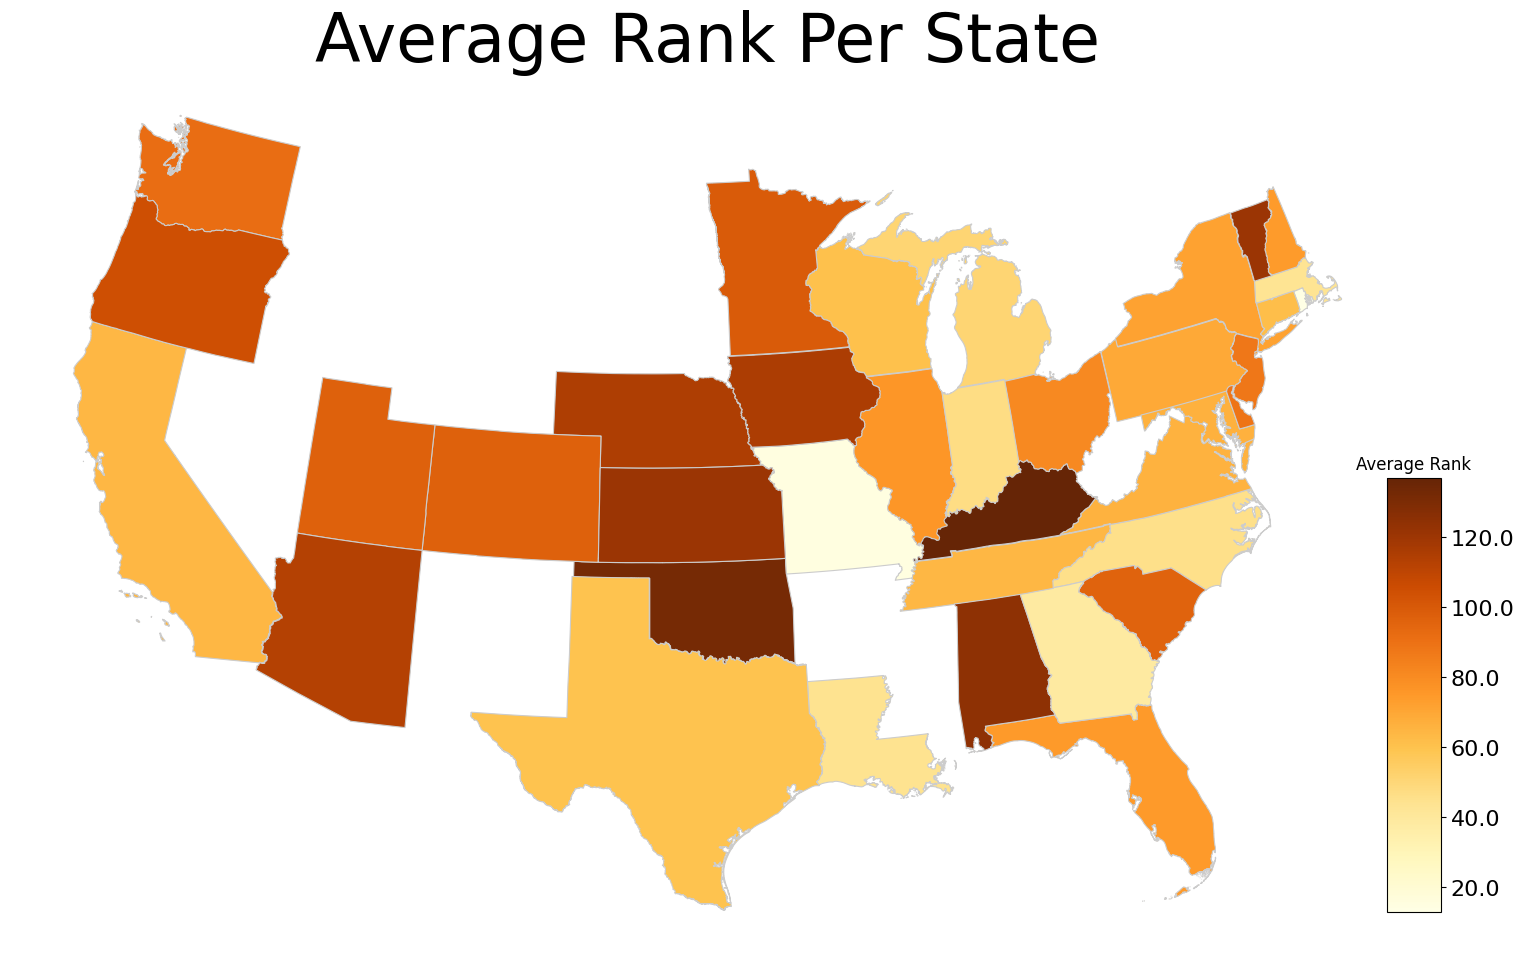

In [11]:
plot_data('Rank', 'Average Rank Per State', 'Average Rank')

In [ ]:
plot_data('Application', 'Applications Per State', 'Applications Per State')

### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [13]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

# Ethics & Privacy

We are fortunate that the topic of this project is relatively free of bias as the data we are collecting and analyzing comes from universities and is general demographic data. It would not contain personal information of any individuals, and so we avoid issues of informed consent or data security. There may however be some form of reporting bias in our data, as a college may attempt to manipulate their ranking. To mitigate this we will take a more broad approach, analysing multiple rankings in order to mitigate influence from the colleges themselves. We may also encounter issues with confounding variables, as the effect of admissions could be changed by differing factors such as admissions cost. Because college rankings are not determined by one fixed formula or authority, we will need to collect multiple sets of rankings in order to lessen the biases of any one specific ranking.  Though the topic we are discussing is relatively free of bias in theory, we may inadvertently add due to our opinions on colleges or simply the decisions we make for analysis.  One way this could occur is in the ranking data we use.  Because we are aggregating multiple rankings, how we weigh each ranking will in turn value the aspects of those rankings.  For example the US News & World Report prioritizes graduation rate performance, so by using those rankings our final rankings will value that statistic as well.

# Team Expectations 

 - We will communicate in our Discord server and will try to respond in the same day if possible.
 - In terms of tone we will express issues politely and directly, explaining what the issue is clearly but politely working to resolve it.
 - Major project decisions will be unanimous, though for lesser components whoever is tasked to complete it will have authority.
 - If someone is struggling to complete work they should bring it up to the team as soon as possible where we can discuss who can pick up the slack or perhaps rescope the project to be less taxing.

# Project Timeline Proposal





| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 4/23  |  4 PM | Read past COGS 108 projects, consider pros and cons when reading  | Complete the Project Review, write down what we liked or what need to improve on for the past projects | 
| 4/30  |  4 PM |  Do background research on topic | Discuss ideal datasets and ethics; where would we draw data; draft project proposal | 
| 5/6  |  2:30 PM |  Find datasets that we can use to answer our question. Find datasets regarding university rankings and IPEDS data | Discuss ideas about what kind of data we need to find and what kind of data we need to get rid of from the datasets we found|
| 5/13  | 2:30 PM  |  Import & wrangle data | Discuss wrangling and possible analytical approaches; Assign what each group memeber's responsibilities are. Also discuss and implement the fixes we need to make to gain points back on our project proposal  |
| 5/21  | 3:00 PM  | Clean data and get rid of unwanted values(Daniel & Jiahao), do some analysis with the data(Hamzah); EDA(All of us); Create data visualization models(Lukas) | Review/Edit wrangling/EDA; Discuss Analysis Plan. Try to discuss what parts of the data we want to analyze and figure out what types of graphs would be best to interpret our data.  |
| 5/27  | 2:30 PM  | Finalize wrangling/EDA; Begin Analysis  | Discuss/edit Analysis; Complete project check-in. Finalize discussions about how we want to analyze our data |
| 6/03  | 2:30 PM  | Complete analysis; Draft results/conclusion/discussion| Discuss/edit full project. Check all of our data and graphs to make sure that they all have value in reinforcing our analysis. Doublecheck the analysis to make sure there are no basic errors (grammer, puncuation, formatting, etc). Disucss when and how we want to record our video and prepare for submission|
| 6/13  | Before 11:59 PM  | NA | Turn in Final Project; Video; Team eval survey & group Project Surveys |